In [ ]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 1.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=118a367fc6e53e7358d5f13672e34c1e064b8e9d62ea48a98588667aac89b6ec
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss
###NEW###
import lifelines

#Survival analysis

- https://lifelines.readthedocs.io/en/latest/Survival%20Analysis%20intro.html

**Chat**, what's survival analysis about?
### Typical Dataset
Drosophila flies: two groups
- T = Time until death
- E = 1 <=> Death observed
- E = 0 <=> Unobserved (e.g. fly escaped from the container)

**Chat**, what's MiR-137? what happen to drosophila flies when it's deactivated? just the TL;DR and ELI5 please

In [ ]:
from lifelines.datasets import load_waltons
df = load_waltons()
df.head()

,T,E,group
0,6.0,1,miR-137
1,13.0,1,miR-137
2,13.0,1,miR-137
3,13.0,1,miR-137
4,19.0,1,miR-137


<Axes: >

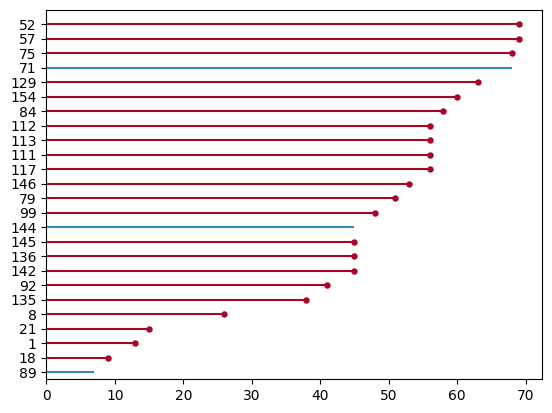

In [ ]:
from lifelines.plotting import plot_lifetimes
df2=df.sample(25)
plot_lifetimes(df2["T"],df2["E"])

<Axes: xlabel='group', ylabel='T'>

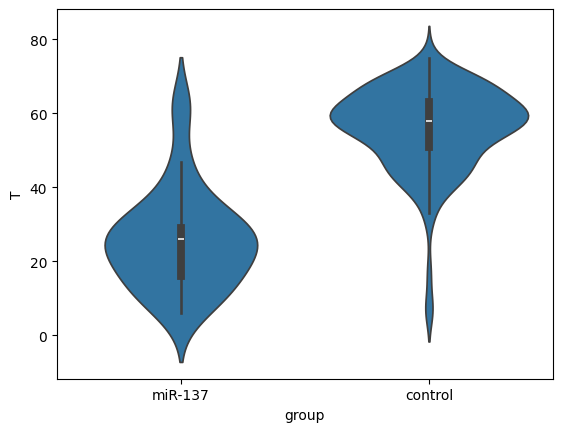

In [ ]:
sns.violinplot(x = 'group', y = 'T', data = df)

<Axes: xlabel='E', ylabel='T'>

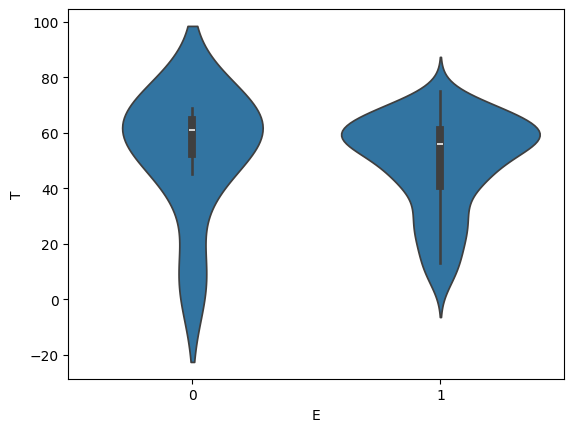

In [ ]:
sns.violinplot(x = 'E', y = 'T', data = df)

**Chat**, I get negative values in this violin plot even though the data is positive, what gives?

In [ ]:
df.describe()

,T,E
count,163.000000,163.000000
mean,49.613497,0.957055
std,17.078007,0.203357
min,6.000000,0.000000
25%,41.000000,1.000000
50%,56.000000,1.000000
75%,61.000000,1.000000
max,75.000000,1.000000


#Default: T~Exp(λ)
 - https://en.wikipedia.org/wiki/Exponential_distribution#Occurrence_and_applications
 - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html

**Chat**, why is the exponential the default distribution for measuring the time until the occurrence of an event?

7.0 49.08196721311475


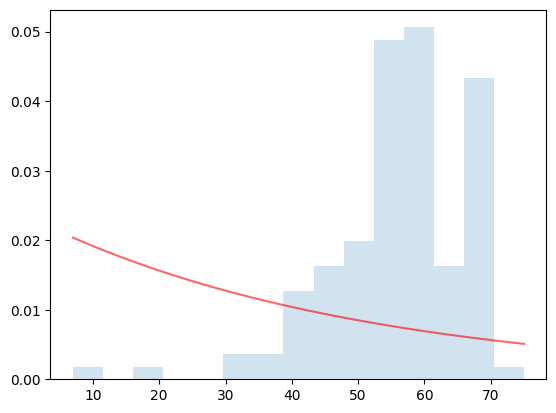

In [ ]:
from scipy.stats import expon
control = df[df['group'] == 'control']
observed = control[control["E"] == 1]

loc, scale = expon.fit(observed["T"])
RV = expon(loc,scale)
print(loc, scale)

x = np.linspace(control["T"].min(), control["T"].max(), 100)
plt.plot(x, RV.pdf(x),'r-', alpha=0.6);
plt.hist(observed["T"], density=True, bins='auto', histtype='stepfilled', alpha=0.2);

dist.fit = MLE

   https://rpsychologist.com/likelihood/

**Chat**,
1. What's a MLE fit? show me the likelihood of an exponential model given a data vector x
2. Why is the exponential not a great model for days of survival of Drosophila flies? Give me some alternatives.


6.697501428887955 0 60.03172610273826


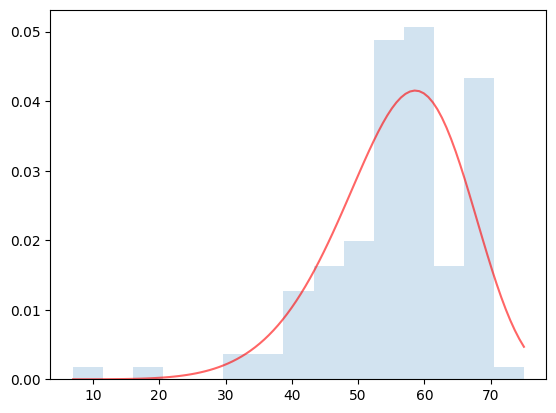

In [ ]:
from scipy.stats import weibull_min
params = weibull_min.fit(observed["T"], floc=0)
RV = weibull_min(*params)
print(*params)

x = np.linspace(control["T"].min(), control["T"].max(), 100)
plt.plot(x, RV.pdf(x),'r-', alpha=0.6);
plt.hist(observed["T"], density=True, bins='auto', histtype='stepfilled', alpha=0.2);

In [ ]:
LL1 = np.sum(expon.logpdf(observed["T"], loc, scale))
LL2 = np.sum(weibull_min.logpdf(observed["T"], *params))
print (LL1, LL2)

-597.005987498364 -456.2085090891749


**Chat**,
1. I fit two distributions to the same data using MLE. How do I compare them?
2. How do I take into account (right) censored data when fitting a Weibull distribution to a survival time data? Can I do it with `scipy.stats`? What's the likelihood function in this case?

6.652040944140465 60.59995669090547


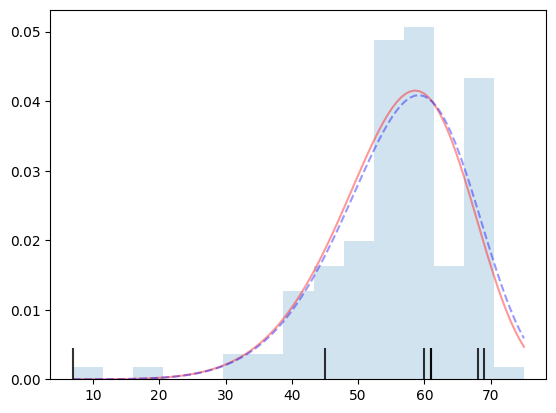

In [ ]:
from lifelines import WeibullFitter
wf = WeibullFitter()

wf.fit(control["T"], event_observed=control["E"]);

lambda_ = wf.lambda_
rho_ = wf.rho_
print(rho_, lambda_)
# Plot PDF from lifelines parameters
x = np.linspace(control["T"].min(), control["T"].max(), 100)
pdf = (rho_ / lambda_) * (x / lambda_)**(rho_ - 1) * np.exp(-(x / lambda_)**rho_)

plt.plot(x, RV.pdf(x) , 'r-', alpha=0.4)
plt.plot(x, pdf, 'b--',alpha=0.4)
plt.hist(observed["T"], density=True, bins='auto', histtype='stepfilled', alpha=0.2);

censored = control[control["E"] == 0]
plt.scatter(censored["T"], np.zeros_like(censored["T"]),
            marker='|', color='k', label="Censored", alpha=0.8, s=2000)


**Chat**,
1. When fitting a Weibull, why is loc = 0 the defualt in survival analysis?
2. I fit a parametric pdf to my survival time data (say a Weibull), what can I do with it now?

![map[1].png]()

https://lifelines.readthedocs.io/en/stable/_images/map.png

**Chat**,
1. Assume I know nothing about survival analysis and explain this figure: <copy & paste>
2. Show me the different definitions of the hazard function, and the proof that they're equivalent.
3. Explain what the bathtub curve is, why it's common in real life survival analysis data and why it makes the exponential a poor model for such data.

  - https://en.wikipedia.org/wiki/Bathtub_curve

4. Why is a Weibull distribution a better model? What are its limitations with regards to modelling the hazard rate?





#Nonparametric approaches:
- use the empirical CDF.
$$S(t)=1-CDF(t)$$

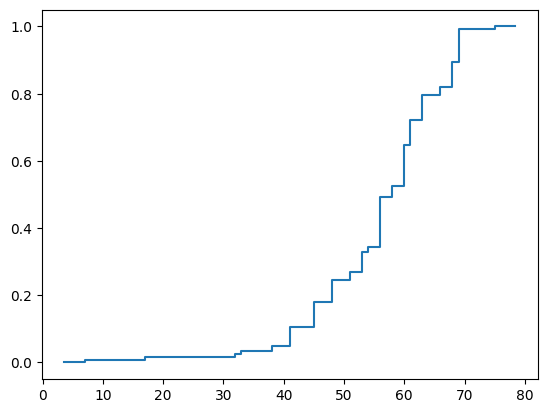

In [ ]:
import scipy.stats
ecdf = scipy.stats.ecdf(observed["T"])
ecdf.cdf.plot()

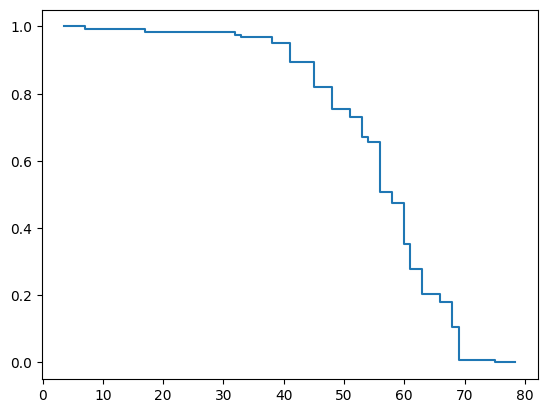

In [ ]:
ecdf.sf.plot()

### What about censored data?

**Chat**,
1. What's wrong with the naive estimator of the survival function? I'm talking about 1-ecdf where we treat censored data as if they failed at censoring time. Make sure to mention underestimation and variance at the tail.
2. What's the Kaplan-Meier estimator and why is it better?
3. Explain the derivation in the PDF file (Kaplan Meier from course website). What does this tell us about the KM estimator?
4. Show that the KM estimator is the MLE of the discrete survival function given the sequence of failure times and number of failures at each time.


          KM_estimate
timeline             
0.0          1.000000
7.0          0.992248
17.0         0.984435
32.0         0.976622
33.0         0.968809


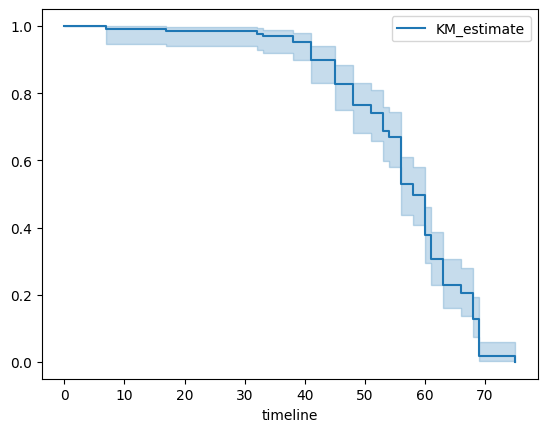

In [ ]:
kmf = lifelines.KaplanMeierFitter()
kmf = kmf.fit(control["T"], control["E"])
print(kmf.survival_function_.head())
kmf.plot();

**Chat**,
1. How do they calculate the CIs in `lifelines.KaplanMeierFitter()`? Make sure to mention Greenwood's formula, the log(-log(x)) transform and the delta method.
5. Why the log(-log(x)) transform? plot a figure.
2. Explain the delta method and its use.
3. Derive Greenwood's formula from first principles (using the delta method). Assume independence between failure times.
  - But the intervals between failure times aren't independent: d_i affects n_i+1. Handwave this away with the martingale CLT. Don't go into details.


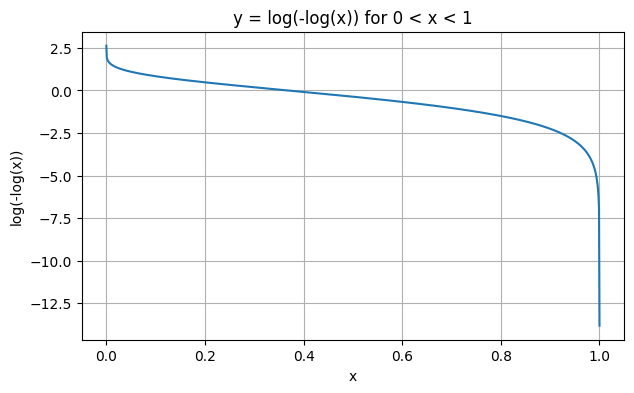

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Avoid 0 and 1 because log(-log(x)) is singular there
x = np.linspace(1e-6, 1 - 1e-6, 1000)
y = np.log(-np.log(x))

plt.figure(figsize=(7, 4))
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("log(-log(x))")
plt.title("y = log(-log(x)) for 0 < x < 1")
plt.grid(True)
plt.show()

#### Model the cumulative hazard = $\int_0^th(x)dx$.

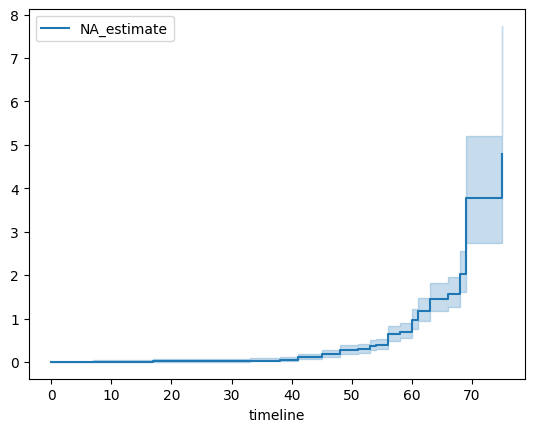

In [ ]:
naf = lifelines.NelsonAalenFitter()
naf1=lifelines.NelsonAalenFitter()
naf1.fit(control["T"], control["E"])
ax = naf1.plot_cumulative_hazard()

**Chat**,
1. Compare and contrast the Nelson Aalen and the Kaplan Meier estimators. When should I use which?
2. If I want to estimate the cumulative hazard, why not just take -log(KM)? Make sure to mention change-of-variable bias and Jensen's inequality.

#Multiple groups

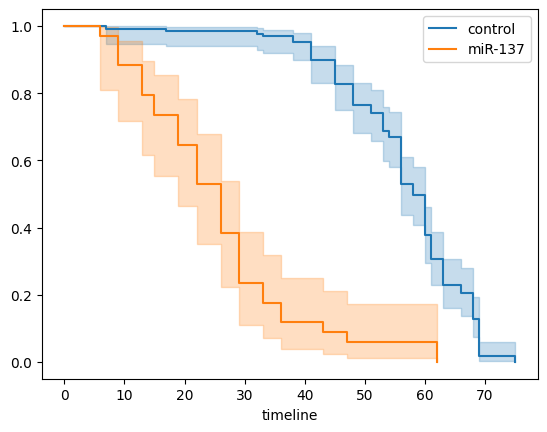

In [ ]:
groups = df['group']
mir_idx = (groups == 'miR-137')

kmf1=lifelines.KaplanMeierFitter()
kmf1.fit(df[~mir_idx]["T"], df[~mir_idx]["E"], label='control')
ax = kmf1.plot_survival_function()


kmf2=lifelines.KaplanMeierFitter()
kmf2.fit(df[mir_idx]["T"], df[mir_idx]["E"], label='miR-137')
ax = kmf2.plot_survival_function(ax=ax)

**Chat**, Analyze this figure. What's the next step? Mention the log-rank test and Cox regression.

#Cox model

**Chat**,
1. Explain the Cox proportional hazards model in survival analysis. Start with reminding me what hazard means. Explain why it's semi-parametric and discuss the partial likelihood trick.
  - Explain why the likelihood looks like this. Start by discussing the probability of failure in a small dt.
  - Why is there no intercept in the Cox model? Show how the base hazard rate would absorb it.
2. Hazard ratios are reported in mass media headlines. Give me some mock examples and connect them to Cox's model.
3. What are the assumptions of the cox model on the data?
4. Why do crossing KM curves indicate that the proportional hazards assumption is violated? Draw figures to illustrate the two cases. Use python and run the code.
5. Give me some real life examples where proportional hazards don't make sense.



In [ ]:
df2 = df.replace({"control":0, "miR-137":1})
print(df2.head())

      T  E  group
0   6.0  1      1
1  13.0  1      1
2  13.0  1      1
3  13.0  1      1
4  19.0  1      1


<ipython-input-17-e1a7139c386a>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2 = df.replace({"control":0, "miR-137":1})


In [ ]:
cph = lifelines.CoxPHFitter()
cph.fit(df2, duration_col="T", event_col="E")
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 163 total observations, 7 right-censored observations>
             duration col = 'T'
                event col = 'E'
      baseline estimation = breslow
   number of observations = 163
number of events observed = 156
   partial log-likelihood = -613.18
         time fit was run = 2025-05-07 11:03:40 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
group      2.05      7.79      0.22            1.63            2.48                5.09               11.91

           cmp to    z      p  -log2(p)
covariate                              
group        0.00 9.46 <0.005     68.14
---
Concordance = 0.66
Partial AIC = 1228.36
log-likelihood ratio test = 66.25 on 1 df
-log2(p) of ll-ratio test = 51.16

**Chat**,
1. Explain this lifelines output. <copy & paste>
2. How do you calculate concordance? What's a good concordance score?

<Axes: >

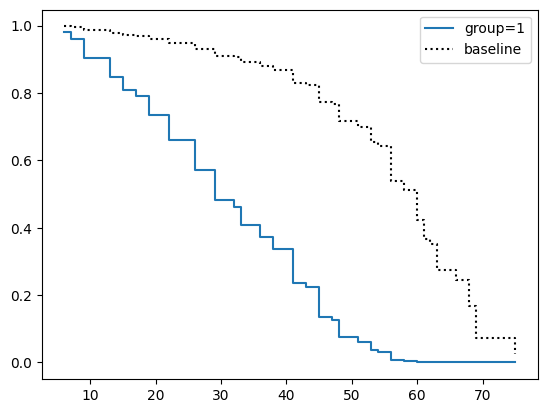

In [ ]:
cph.plot_partial_effects_on_outcome(covariates="group", values=[1])

Chat,
1. If the Cox model doesn't specify the base hazard rate, how come I can draw the survival function with `cph.plot_partial_effects_on_outcome`? Make sure to mention Breslow's estimator.
2. What's the intuition behind Breslow's estimator?
3. Why not just use the KM estimator instead of Breslow's with Cox regression?

#Regression QA
like OLS.


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.01. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 163 total observations, 7 right-censored observations>
         test_name = proportional_hazard_test

---
            test_statistic      p  -log2(p)
group km             14.03 <0.005     12.44
      rank           13.26 <0.005     11.85



1. Variable 'group' failed the non-proportional test: p-value is 0.0002.

   Advice: with so few unique values (only 2), you can include `strata=['group', ...]` in the call
in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



[[<Axes: xlabel='rank-transformed time\n(p=0.0003)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0002)'>]]

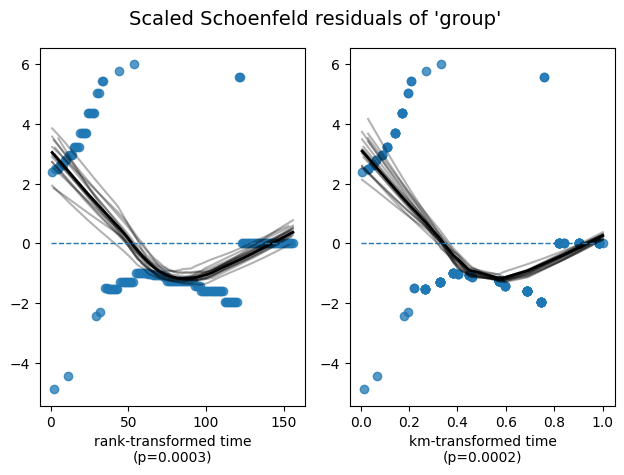

In [ ]:
cph.check_assumptions(df2,show_plots=True)

**Chat**,
1. Analyze this.
2. What should I look for in this figure?
3. What are scaled Schoenfeld residuals? rank transformed time? km transformed time?

#Go further:

**Chat**,
1. If the assumptions of the Cox proportional hazards model are violated, what should I do?
1. Compare `scikit-survival` vs `lifelines`. Discuss pros and cons.
